# State Storage Size Impact on State Access Parameters

#### Maria Silva, March 2026

Investigate how storage size (encoded by `token_name`) impacts the runtime of cold **SLOAD** and **SSTORE** operations. We focus on:

- `test_sload_erc20_balanceof` (SLOAD)
- `test_sstore_erc20_mint` (SSTORE)

with `cache_strategy=NO_CACHE`.

**Key questions:**
1. Are the NNLS regression fits good enough (R², p-values) across all token sizes?
2. Do estimated runtimes increase linearly with storage size?
3. Is the behavior different across clients and existing/non-existing slot variants?

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy.stats import spearmanr, kendalltau, theilslopes
from itertools import permutations

warnings.filterwarnings("ignore")

In [ ]:
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))
src_dir = os.path.join(repo_dir, "src")
sys.path.append(src_dir)

from data import process_gas_bench_data
from nnls import fit_NNLS_without_low_diff_runs
from runtime_estimation import prepare_non_simple_model_data

In [3]:
# Secrets for acessing xatu clickhouse and erigon
with open(os.path.join(repo_dir, "secrets.json"), "r") as file:
    secrets_dict = json.load(file)

# Credentials for gas bench postgresql and benchmarkoor
user = secrets_dict["gas_bench_username"]
password = secrets_dict["gas_bench_password"]
bearer_token = secrets_dict["benchmarkoor_bearer_token"]

## 1. Load and filter data

In [4]:
start_date = "2026-03-04"
query_source = "benchmarkoor"

df, trace_df = process_gas_bench_data(
    network="perf_devnet_3",
    test_type="stateful",
    start_date=start_date,
    source=query_source,
    user=user,
    password=password,
    bearer_token=bearer_token,
)

print(f"Total rows: {len(df)}")
print(f"Test names: {sorted(df['test_name'].unique())}")
print(f"Token names: {sorted(df['token_name'].dropna().unique())}")

Querying benchmarkoor database....


Fetching test_stats: 100%|██████████| 6/6 [00:04<00:00,  1.35it/s]


Total rows: 50585
Test names: ['test_account_access', 'test_ext_account_query_warm', 'test_sload_erc20_balanceof', 'test_sstore_erc20_mint', 'test_storage_sload_same_key_benchmark']
Token names: ['1GB_ERC20', '30GB_ERC20', '4_23MB_ERC20', '50GB_ERC20', '9_39GB_ERC20', 'ARB', 'HST', 'USDC', 'XEN']


In [5]:
# Filter to target tests, target token_name, NO_CACHE only
target_tests = ["test_sload_erc20_balanceof", "test_sstore_erc20_mint"]
target_tokens = [
    "4_23MB_ERC20",
    "1GB_ERC20",
    "9_39GB_ERC20",
    "30GB_ERC20",
    "50GB_ERC20",
]
filtered_df = df[
    (df["test_name"].isin(target_tests))
    & (df["token_name"].isin(target_tokens))
    & (df["cache_strategy"] == "NO_CACHE")
].copy()

print(f"Filtered rows: {len(filtered_df)}")
print(f"Opcodes: {filtered_df['test_opcode'].unique()}")
print(f"Clients: {sorted(filtered_df['client_name'].unique())}")
print(f"Token names: {sorted(filtered_df['token_name'].unique())}")
print(f"Existing slots: {filtered_df['existing_slots'].unique()}")
print()
print("Rows per group:")
print(
    filtered_df.groupby(["test_opcode", "client_name", "token_name", "existing_slots"])
    .size()
    .unstack("existing_slots")
    .to_string()
)

Filtered rows: 7306
Opcodes: ['SSTORE' 'SLOAD']
Clients: ['besu', 'geth', 'nethermind', 'reth']
Token names: ['1GB_ERC20', '30GB_ERC20', '4_23MB_ERC20', '50GB_ERC20', '9_39GB_ERC20']
Existing slots: ['False' 'True']

Rows per group:
existing_slots                        False  True
test_opcode client_name token_name               
SLOAD       besu        1GB_ERC20        70    70
                        30GB_ERC20       70    70
                        4_23MB_ERC20     70    70
                        50GB_ERC20       70    70
                        9_39GB_ERC20     70    70
            geth        1GB_ERC20       110   110
                        30GB_ERC20      110   110
                        4_23MB_ERC20    110   110
                        50GB_ERC20      110   110
                        9_39GB_ERC20    110   110
            nethermind  1GB_ERC20        50    50
                        30GB_ERC20       50    50
                        4_23MB_ERC20     50    50
                 

In [ ]:
# Map token names to approximate storage sizes in GB for ordering
TOKEN_SIZE_GB = {
    "4_23MB_ERC20": 0.00413,
    "1GB_ERC20": 1.0,
    "9_39GB_ERC20": 9.39,
    "30GB_ERC20": 30.0,
    "50GB_ERC20": 50.0,
}

filtered_df["storage_size_gb"] = filtered_df["token_name"].map(TOKEN_SIZE_GB)
filtered_df["existing_slots"] = filtered_df["existing_slots"].astype(str)

# Sort token names by size for consistent plotting
token_order = sorted(TOKEN_SIZE_GB.keys(), key=lambda x: TOKEN_SIZE_GB[x])
print("Token order (by storage size):")
for t in token_order:
    print(f"  {t}: {TOKEN_SIZE_GB[t]} GB")

## 2. EDA: runtime vs opcount by token size

Quick visual check — do different storage sizes produce visibly different runtime slopes?

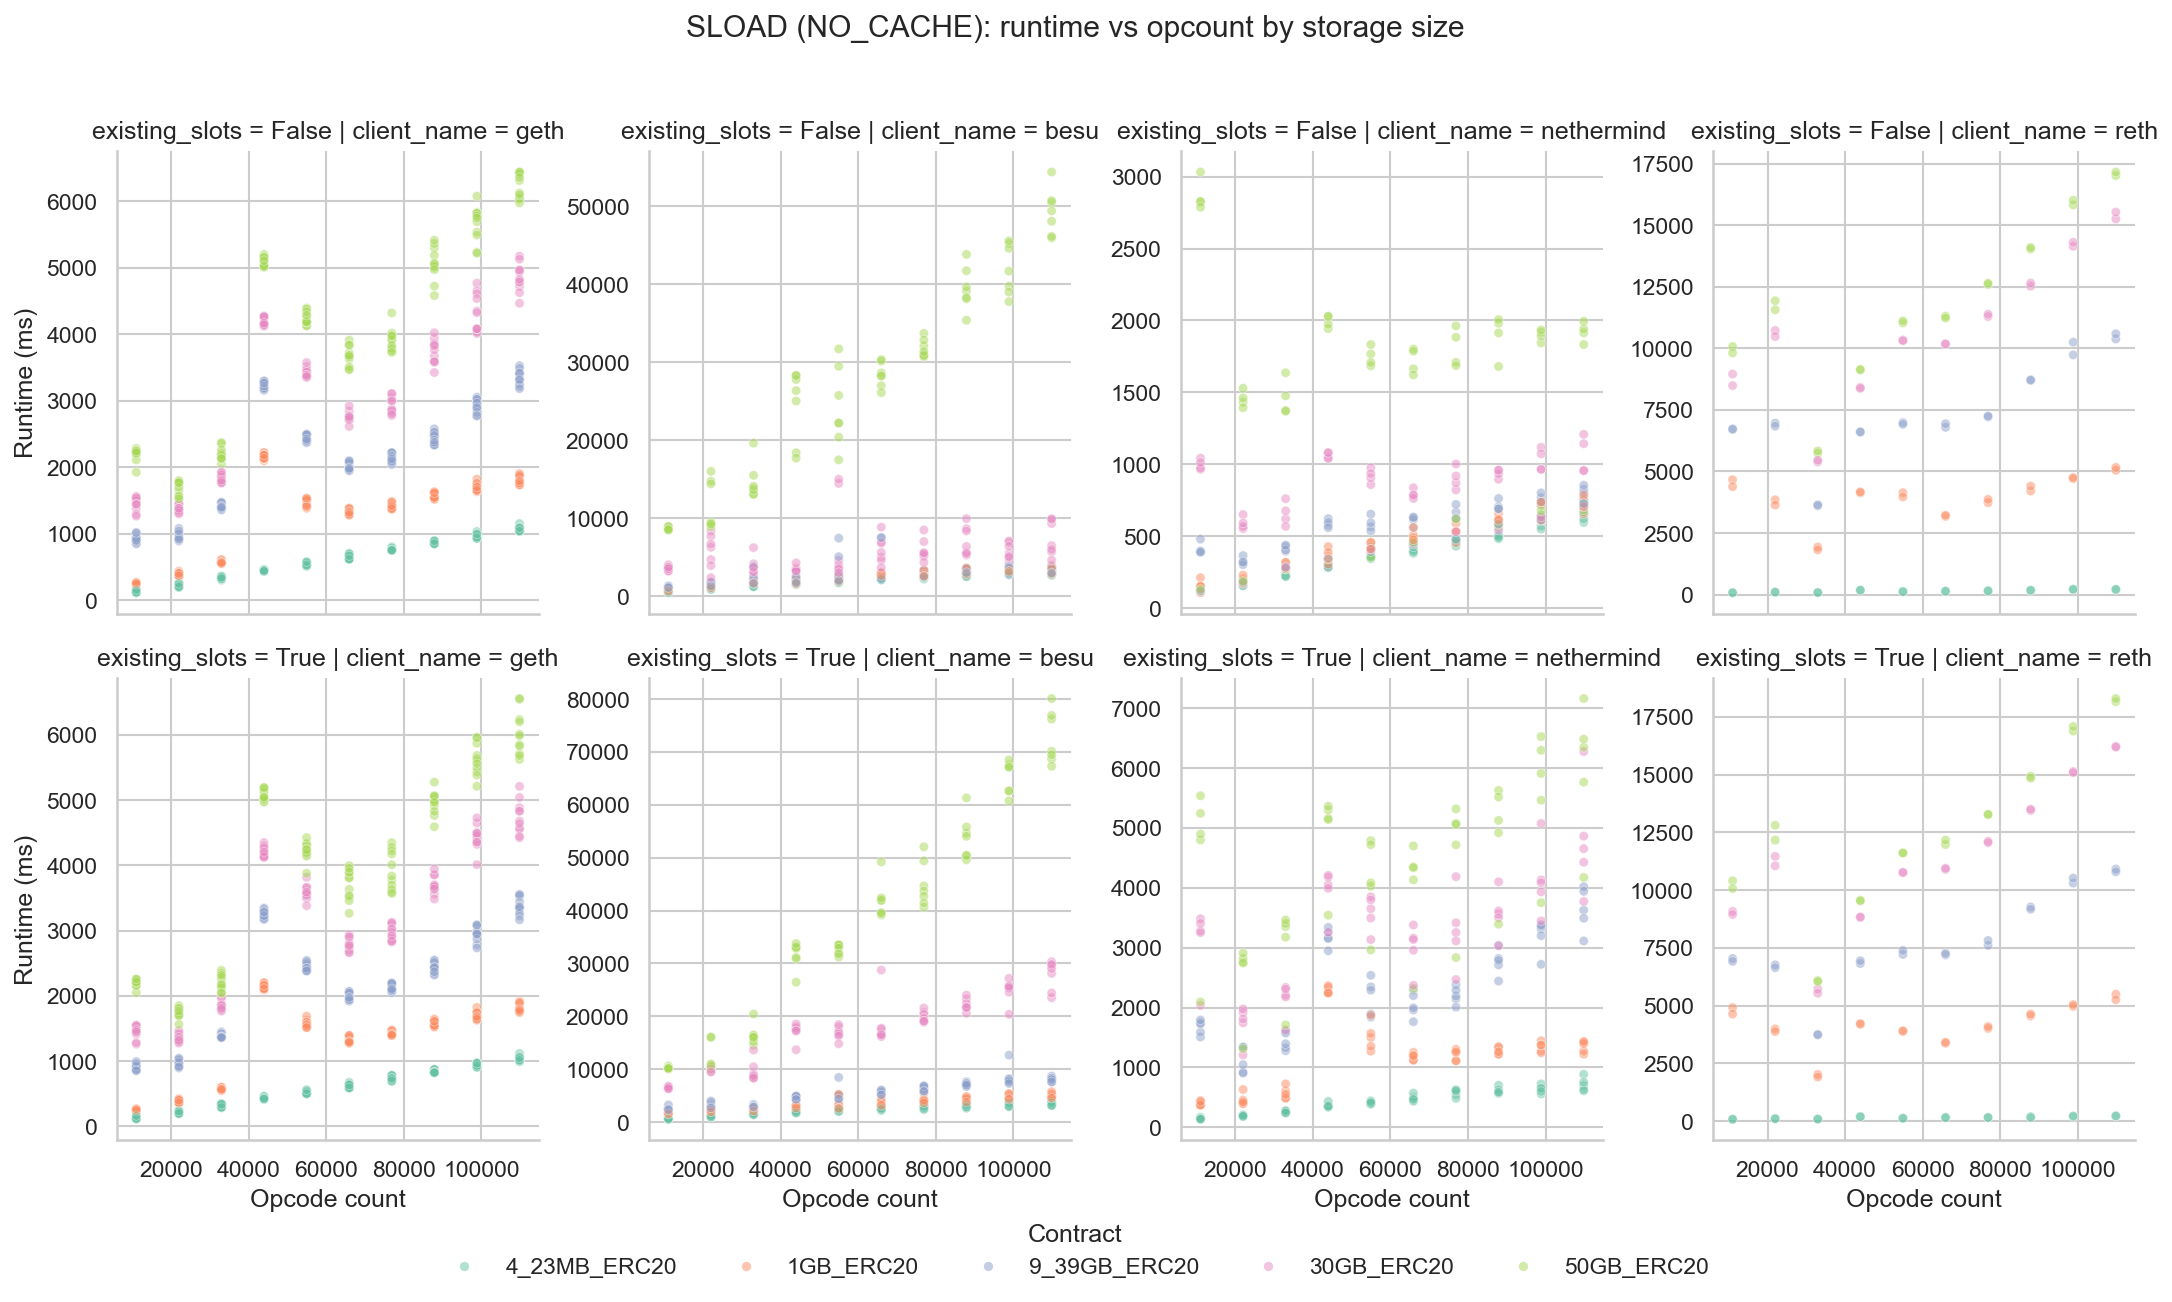

In [7]:
# SLOAD: runtime vs opcount faceted by client, colored by token_name
sload_df = filtered_df[filtered_df["test_opcode"] == "SLOAD"].copy()

g = sns.relplot(
    data=sload_df,
    x="opcount",
    y="run_duration_ms",
    hue="token_name",
    hue_order=token_order,
    col="client_name",
    row="existing_slots",
    kind="scatter",
    alpha=0.5,
    s=20,
    height=4,
    aspect=0.8,
    facet_kws={"sharey": False},
)
g.set_xlabels("Opcode count")
g.set_ylabels("Runtime (ms)")
g.figure.suptitle("SLOAD (NO_CACHE): runtime vs opcount by storage size", y=1.02)
sns.move_legend(g, "lower center", bbox_to_anchor=(0.5, -0.05), ncol=len(TOKEN_SIZE_GB), title="Contract")
plt.tight_layout()
plt.show()

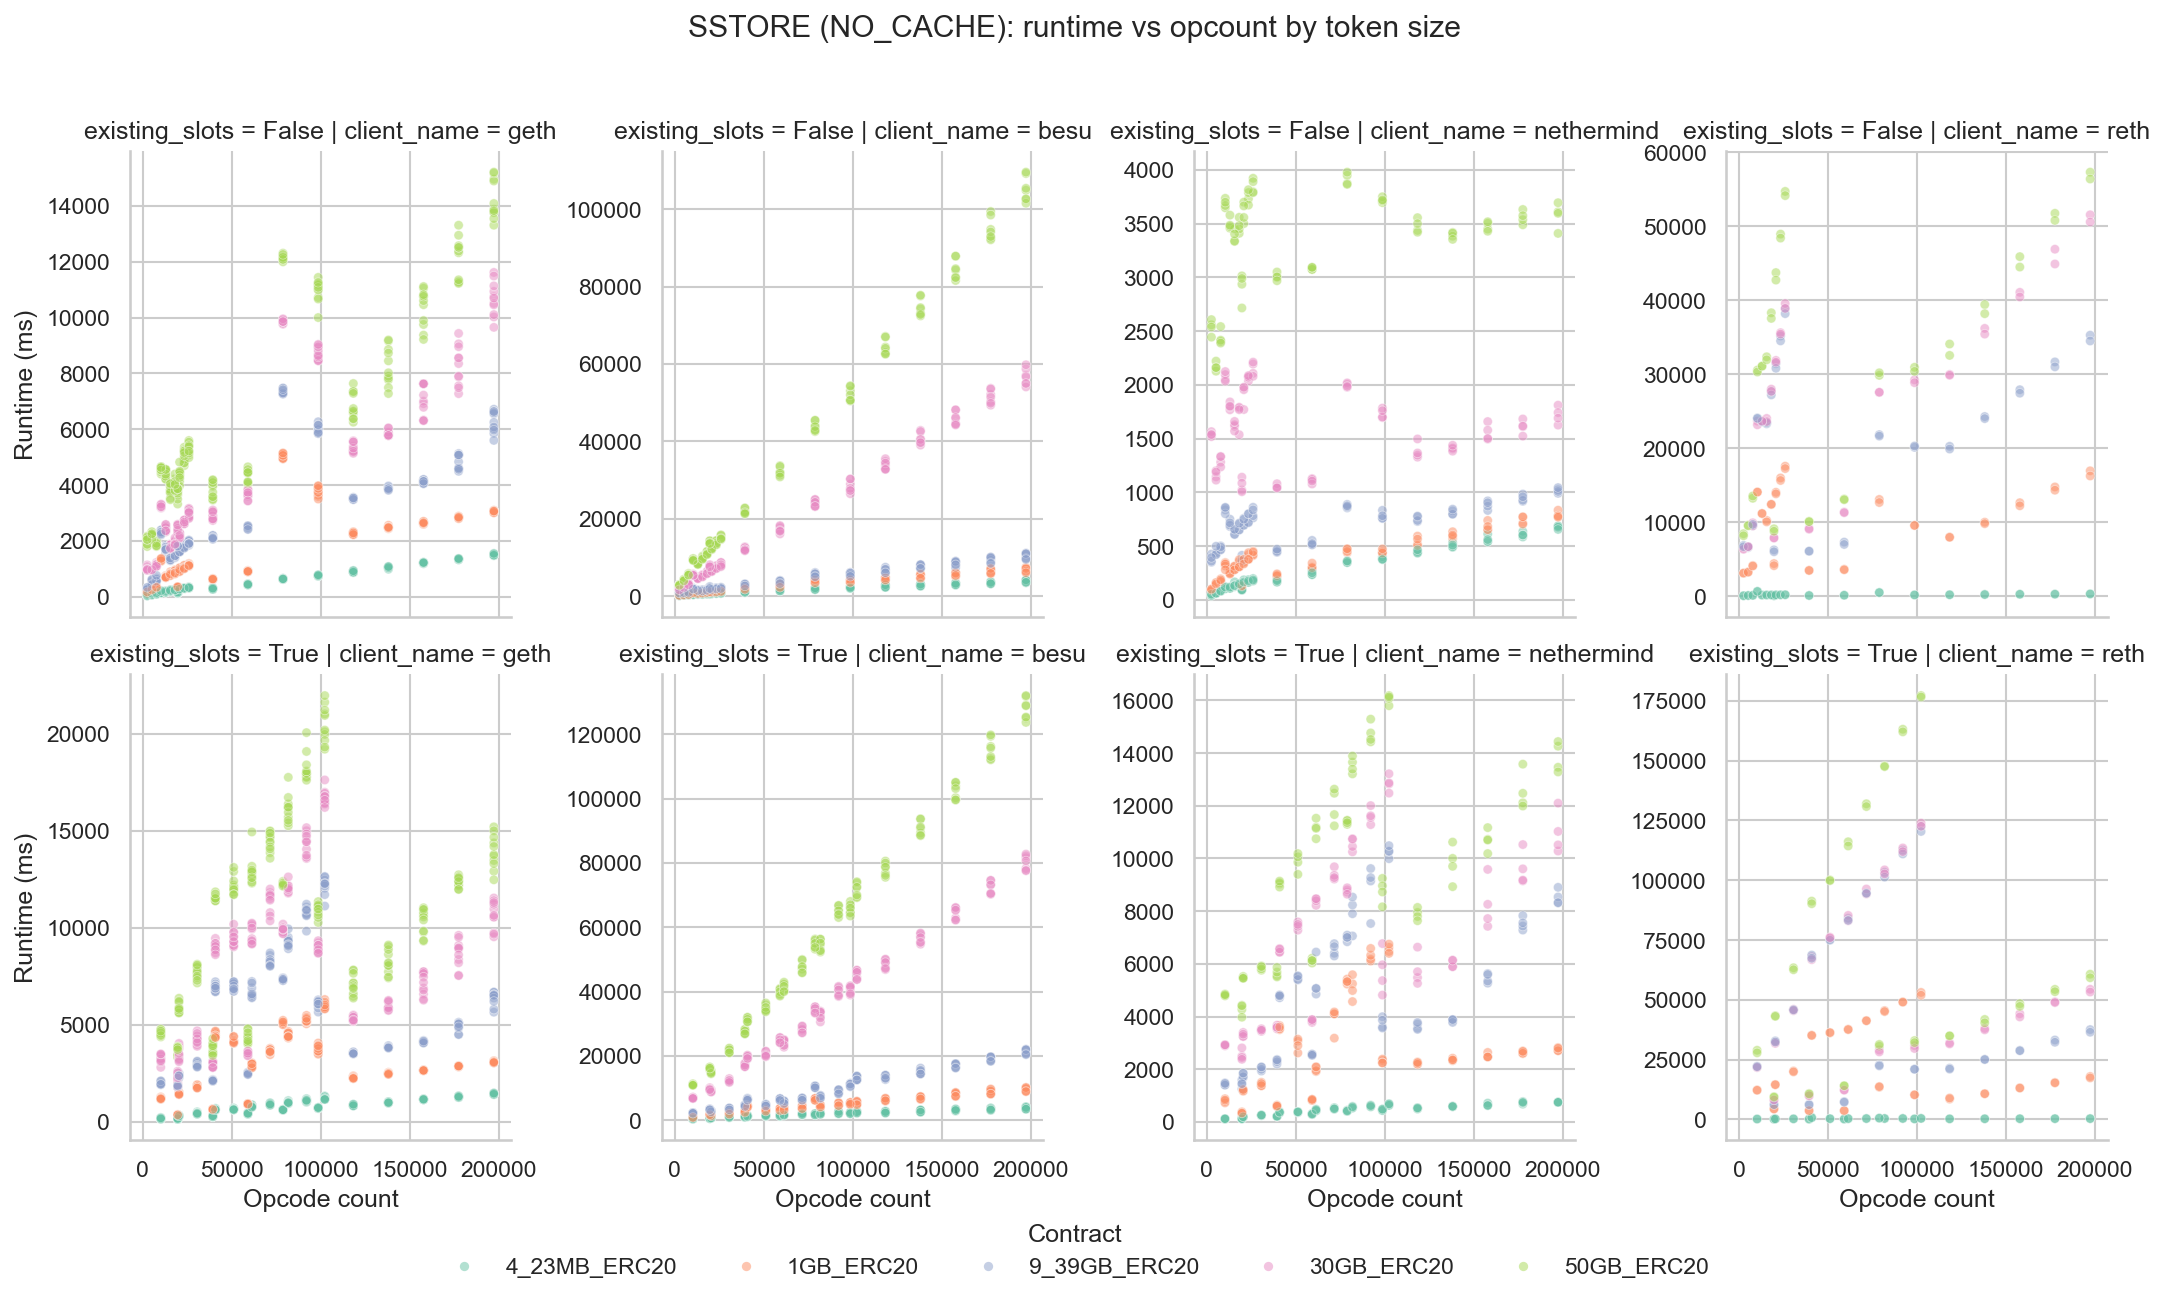

In [8]:
# SSTORE: runtime vs opcount faceted by client, colored by token_name
sstore_df = filtered_df[filtered_df["test_opcode"] == "SSTORE"].copy()

g = sns.relplot(
    data=sstore_df,
    x="opcount",
    y="run_duration_ms",
    hue="token_name",
    hue_order=[t for t in token_order if t in sstore_df["token_name"].unique()],
    col="client_name",
    row="existing_slots",
    kind="scatter",
    alpha=0.5,
    s=20,
    height=4,
    aspect=0.8,
    facet_kws={"sharey": False},
)
g.set_xlabels("Opcode count")
g.set_ylabels("Runtime (ms)")
g.figure.suptitle("SSTORE (NO_CACHE): runtime vs opcount by token size", y=1.02)
sns.move_legend(g, "lower center", bbox_to_anchor=(0.5, -0.05), ncol=len(TOKEN_SIZE_GB), title="Contract")
plt.tight_layout()
plt.show()

## 3. Fit NNLS regression per combination

For each combination of `(test_opcode, client_name, token_name, existing_slots)`, fit a NNLS model:
- **SLOAD**: `run_duration_ms ~ const + opcount` (simple model)
- **SSTORE**: `run_duration_ms ~ const + opcount + update * opcount` (non-simple model, using the `update` feature from `test_params`)

In [9]:
group_cols = ["test_opcode", "client_name", "token_name", "existing_slots"]
results_list = []

for group_values, group_df in filtered_df.groupby(group_cols, dropna=False):
    opcode, client, token, existing = group_values

    if opcode == "SSTORE":
        # Prepare data with update feature
        model_df, features = prepare_non_simple_model_data(group_df.copy(), ["update"])
    else:
        # Simple model: opcount only
        features = ["opcount"]
        model_df = group_df.copy()

    try:
        result = fit_NNLS_without_low_diff_runs(model_df, features)
    except Exception as e:
        print(f"FAILED: {opcode} {client} {token} existing={existing}: {e}")
        continue

    row = {
        "test_opcode": opcode,
        "client_name": client,
        "token_name": token,
        "existing_slots": existing,
        "storage_size_gb": TOKEN_SIZE_GB.get(token, np.nan),
        "nobs": result.nobs,
        "rsquared": result.rsquared,
        "rsquared_adj": result.rsquared_adj,
        "intercept": result.params["const"],
        "intercept_pvalue": result.pvalues["const"],
        "slope": result.params["opcount"],
        "slope_pvalue": result.pvalues["opcount"],
        "slope_conf_int_low": result.conf_int().loc["opcount", 0],
        "slope_conf_int_high": result.conf_int().loc["opcount", 1],
    }

    # Add update coefficient for SSTORE
    if "update" in result.params:
        row["update"] = result.params["update"]
        row["update_pvalue"] = result.pvalues["update"]
        row["update_conf_int_low"] = result.conf_int().loc["update", 0]
        row["update_conf_int_high"] = result.conf_int().loc["update", 1]

    results_list.append(row)

results_df = pd.DataFrame(results_list)
print(f"Fitted {len(results_df)} models")
results_df.head()

Fitted 80 models


,test_opcode,client_name,token_name,existing_slots,storage_size_gb,nobs,rsquared,rsquared_adj,intercept,intercept_pvalue,slope,slope_pvalue,slope_conf_int_low,slope_conf_int_high,update,update_pvalue,update_conf_int_low,update_conf_int_high
0,SLOAD,besu,1GB_ERC20,False,1.000,70,0.888564,0.886925,695.953214,0.0,0.027103,0.0,0.024594,0.029429,NaN,NaN,NaN,NaN
1,SLOAD,besu,1GB_ERC20,True,1.000,70,0.868709,0.866778,1272.188108,0.0,0.035389,0.0,0.033095,0.037947,NaN,NaN,NaN,NaN
2,SLOAD,besu,30GB_ERC20,False,30.000,70,0.164526,0.152240,3631.637906,0.0,0.031924,0.0,0.018809,0.044861,NaN,NaN,NaN,NaN
3,SLOAD,besu,30GB_ERC20,True,30.000,70,0.883962,0.882256,5054.980856,0.0,0.203468,0.0,0.188790,0.216848,NaN,NaN,NaN,NaN
4,SLOAD,besu,4_23MB_ERC20,False,0.004,70,0.930235,0.929209,478.347391,0.0,0.026194,0.0,0.024232,0.028109,NaN,NaN,NaN,NaN


## 4. Model fit quality: R² and p-values

Are the fits good enough across all token sizes, clients, and existing/non-existing variants?

In [10]:
# R² summary by opcode and client
rsq_summary = (
    results_df.groupby(["test_opcode", "client_name"])["rsquared"]
    .agg(["mean", "median", "min", "max", "count"])
    .round(3)
)
print("R² summary across token sizes:")
display(rsq_summary)

R² summary across token sizes:


mean  median    min    max  count
test_opcode client_name                                    
SLOAD       besu         0.770   0.886  0.165  0.960     10
            geth         0.712   0.688  0.536  0.993     10
            nethermind   0.530   0.509  0.000  0.961     10
            reth         0.587   0.661  0.204  0.766     10
SSTORE      besu         0.975   0.978  0.919  0.998     10
            geth         0.780   0.802  0.532  0.998     10
            nethermind   0.795   0.854  0.481  0.990     10
            reth         0.786   0.956  0.090  0.992     10

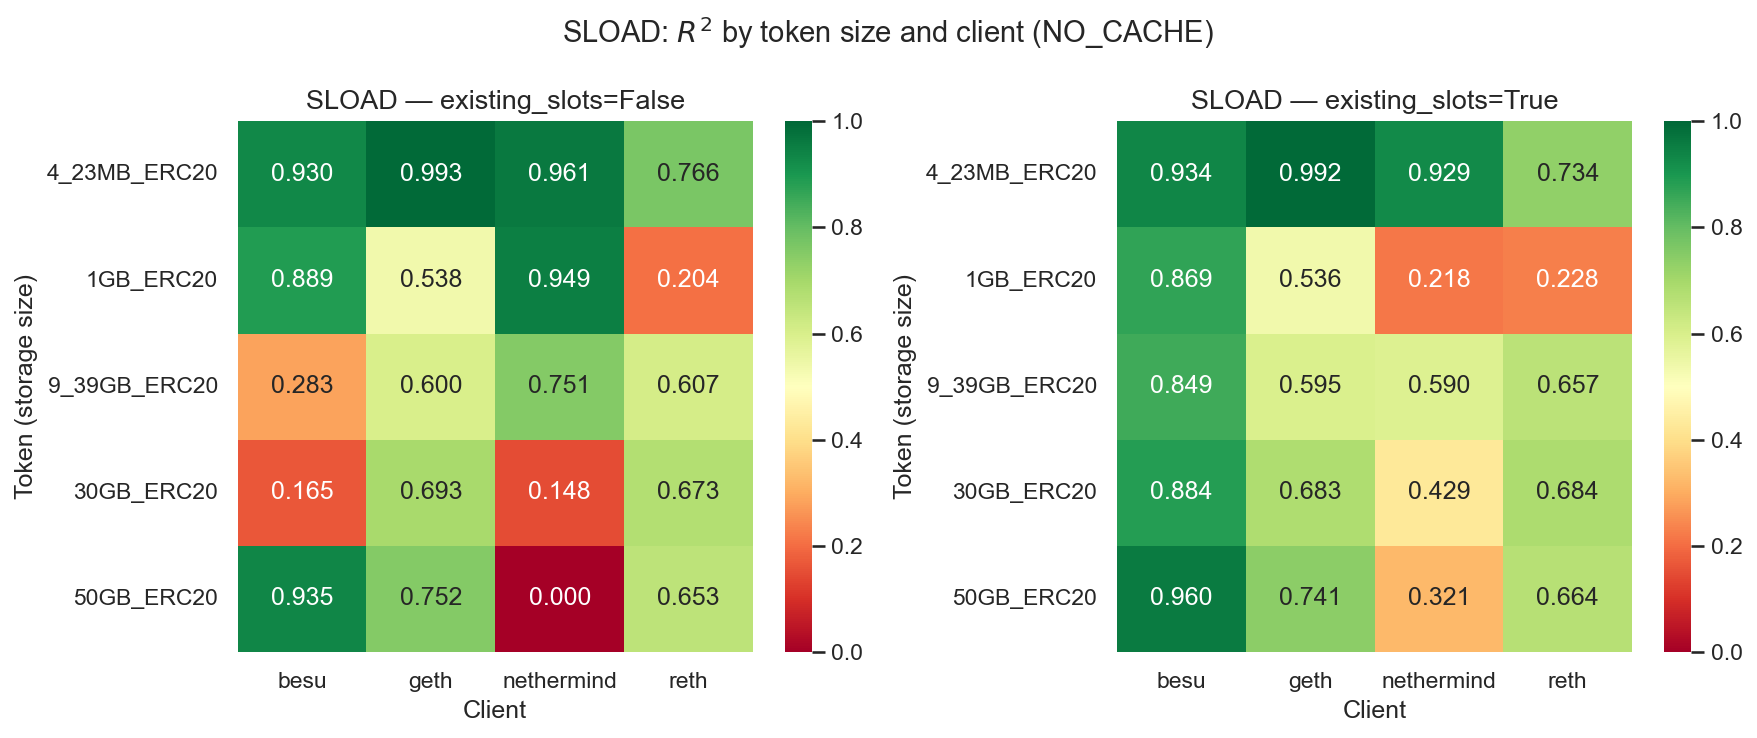

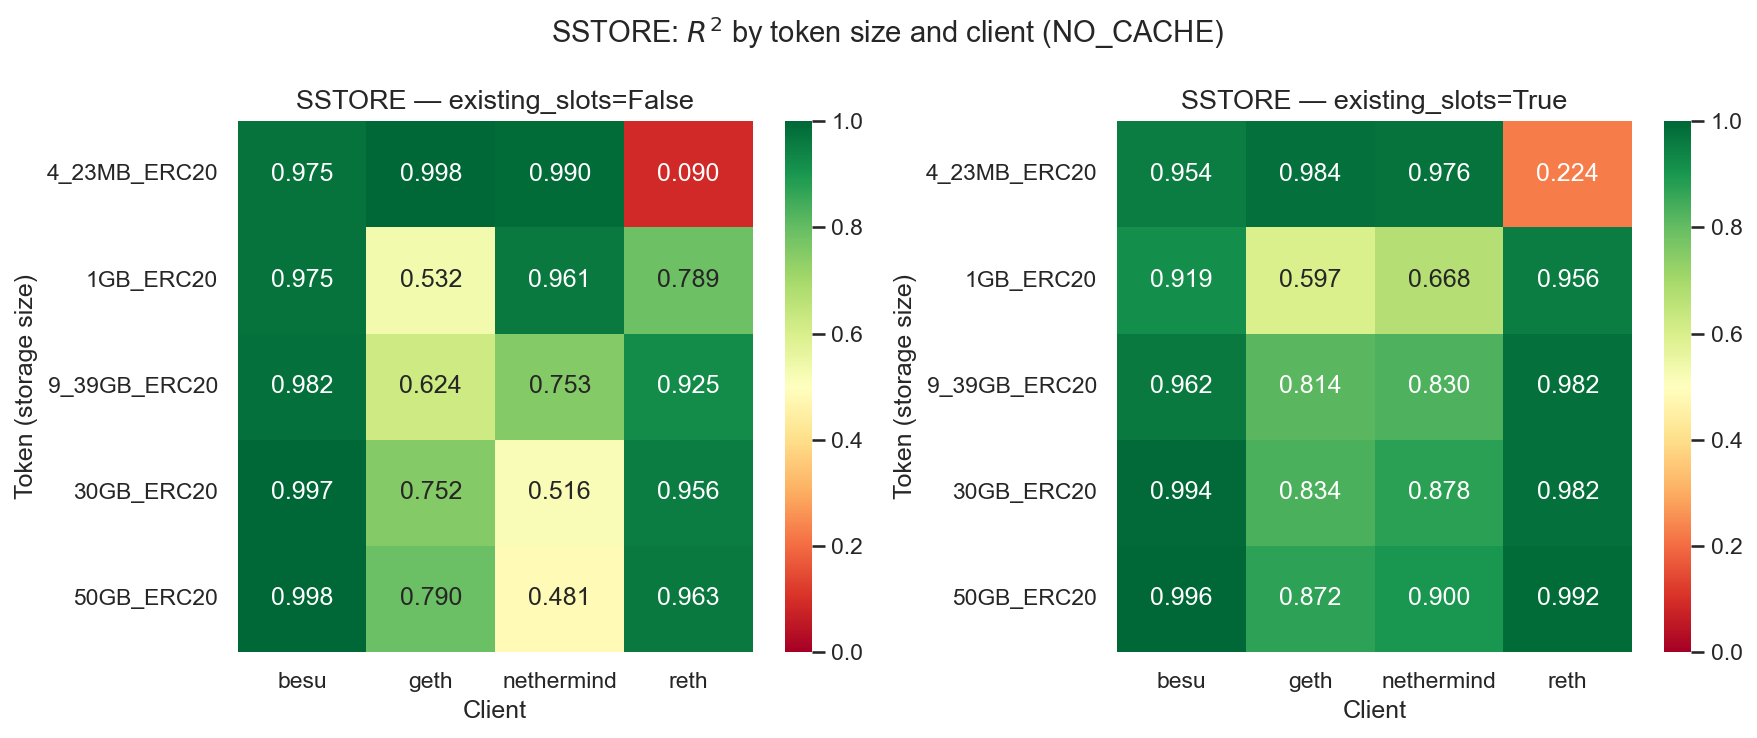

In [11]:
# R² heatmap: token_name vs client, faceted by opcode and existing_slots
for opcode in ["SLOAD", "SSTORE"]:
    op_results = results_df[results_df["test_opcode"] == opcode]
    existing_vals = sorted(op_results["existing_slots"].unique())

    fig, axes = plt.subplots(1, len(existing_vals), figsize=(6 * len(existing_vals), 5))
    if len(existing_vals) == 1:
        axes = [axes]

    for i, existing in enumerate(existing_vals):
        ax = axes[i]
        subset = op_results[op_results["existing_slots"] == existing]
        pivot = subset.pivot_table(
            index="token_name", columns="client_name", values="rsquared"
        )
        # Reorder by storage size
        ordered_tokens = [t for t in token_order if t in pivot.index]
        pivot = pivot.reindex(ordered_tokens)

        sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax)
        ax.set_title(f"{opcode} — existing_slots={existing}")
        ax.set_ylabel("Token (storage size)")
        ax.set_xlabel("Client")

    plt.suptitle(f"{opcode}: $R^2$ by token size and client (NO_CACHE)", fontsize=14)
    plt.tight_layout()
    plt.show()

In [12]:
# P-value analysis: slope significance
print("Slope p-value summary:")
print(
    results_df.groupby(["test_opcode", "client_name"])["slope_pvalue"]
    .agg(["mean", "max"])
    .round(4)
    .to_string()
)
print()

# Flag any models with poor fits (R² < 0.5 or slope p-value > 0.05)
poor_fits = results_df[
    (results_df["rsquared"] < 0.5) | (results_df["slope_pvalue"] > 0.05)
]
if len(poor_fits) > 0:
    print(f"⚠ {len(poor_fits)} models with R² < 0.5 or slope p-value > 0.05:")
    display(
        poor_fits[
            [
                "test_opcode",
                "client_name",
                "token_name",
                "existing_slots",
                "rsquared",
                "slope_pvalue",
            ]
        ].round(4)
    )
else:
    print("All models have R² >= 0.5 and slope p-value <= 0.05")

Slope p-value summary:
                           mean    max
test_opcode client_name               
SLOAD       besu         0.0000  0.000
            geth         0.0000  0.000
            nethermind   0.1004  1.000
            reth         0.0026  0.015
SSTORE      besu         0.0000  0.000
            geth         0.0000  0.000
            nethermind   0.0000  0.000
            reth         0.0049  0.038

⚠ 12 models with R² < 0.5 or slope p-value > 0.05:


,test_opcode,client_name,token_name,existing_slots,rsquared,slope_pvalue
2,SLOAD,besu,30GB_ERC20,False,0.1645,0.000
8,SLOAD,besu,9_39GB_ERC20,False,0.2829,0.000
21,SLOAD,nethermind,1GB_ERC20,True,0.2181,0.000
22,SLOAD,nethermind,30GB_ERC20,False,0.1480,0.003
23,SLOAD,nethermind,30GB_ERC20,True,0.4291,0.000
26,SLOAD,nethermind,50GB_ERC20,False,0.0000,1.000
27,SLOAD,nethermind,50GB_ERC20,True,0.3208,0.001
30,SLOAD,reth,1GB_ERC20,False,0.2042,0.015
31,SLOAD,reth,1GB_ERC20,True,0.2280,0.011
66,SSTORE,nethermind,50GB_ERC20,False,0.4808,0.000


In [13]:
# For SSTORE: also check update coefficient significance
sstore_results = results_df[results_df["test_opcode"] == "SSTORE"]
if "update_pvalue" in sstore_results.columns:
    print("SSTORE update coefficient p-value summary:")
    print(
        sstore_results.groupby("client_name")["update_pvalue"]
        .agg(["mean", "max"])
        .round(4)
        .to_string()
    )

SSTORE update coefficient p-value summary:
               mean    max
client_name               
besu         0.6491  1.000
geth         0.3000  1.000
nethermind   0.0000  0.000
reth         0.0096  0.096


## 5. Impact of storage size on estimated runtimes

The key question: does the NNLS slope (estimated runtime per opcode execution in ms) increase with storage size?

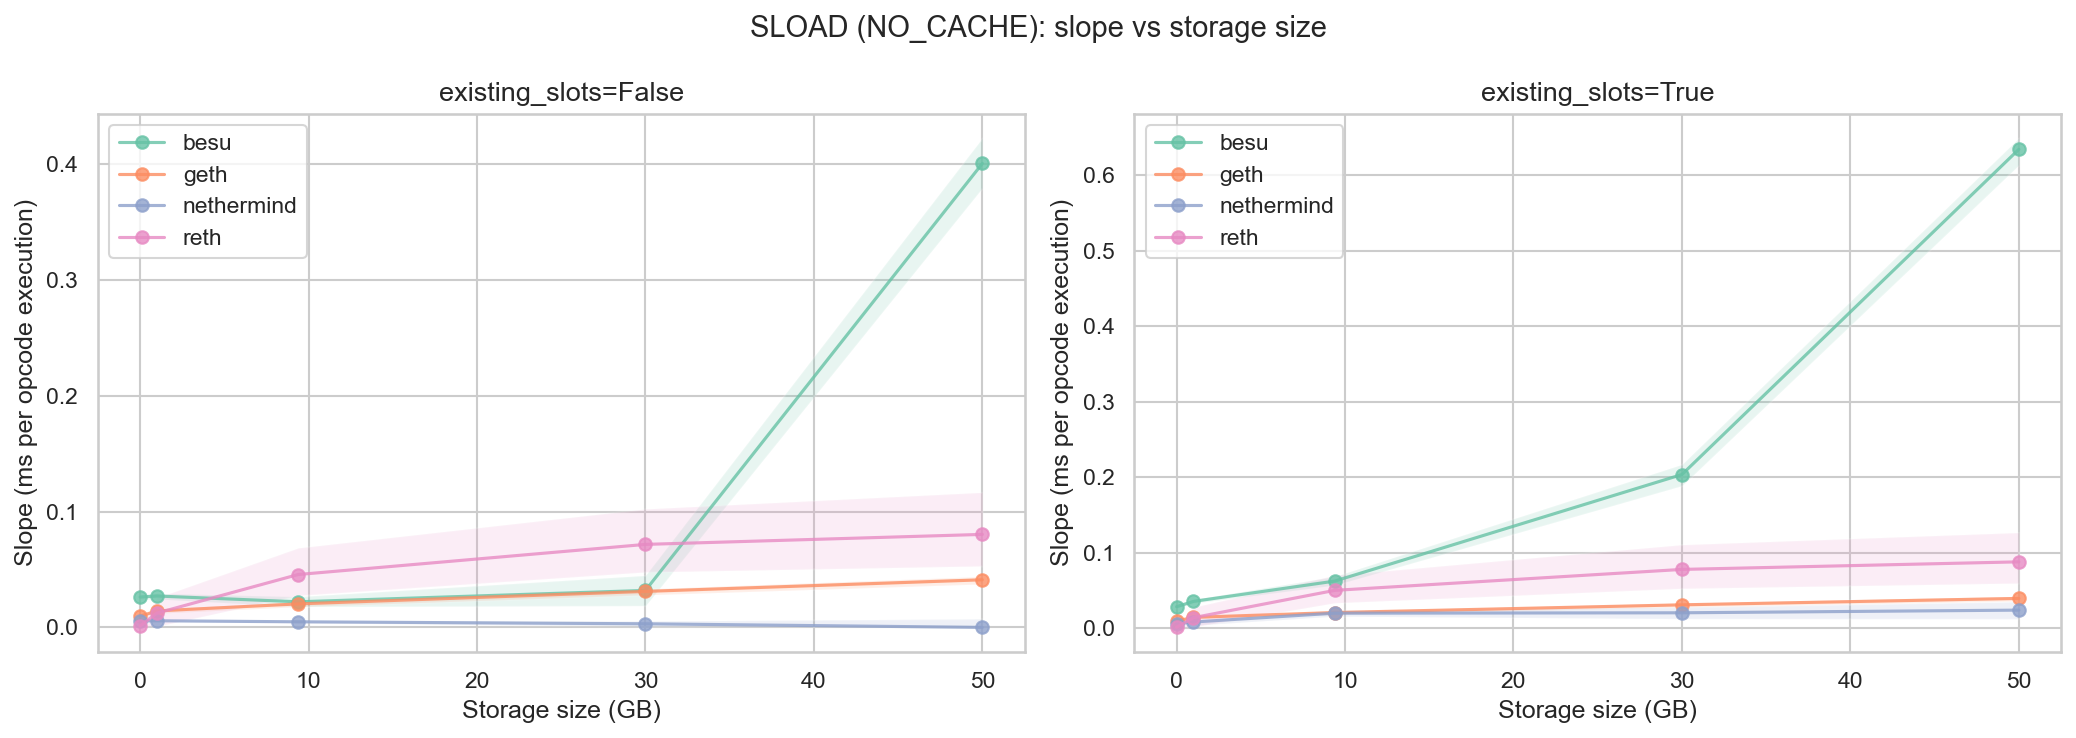

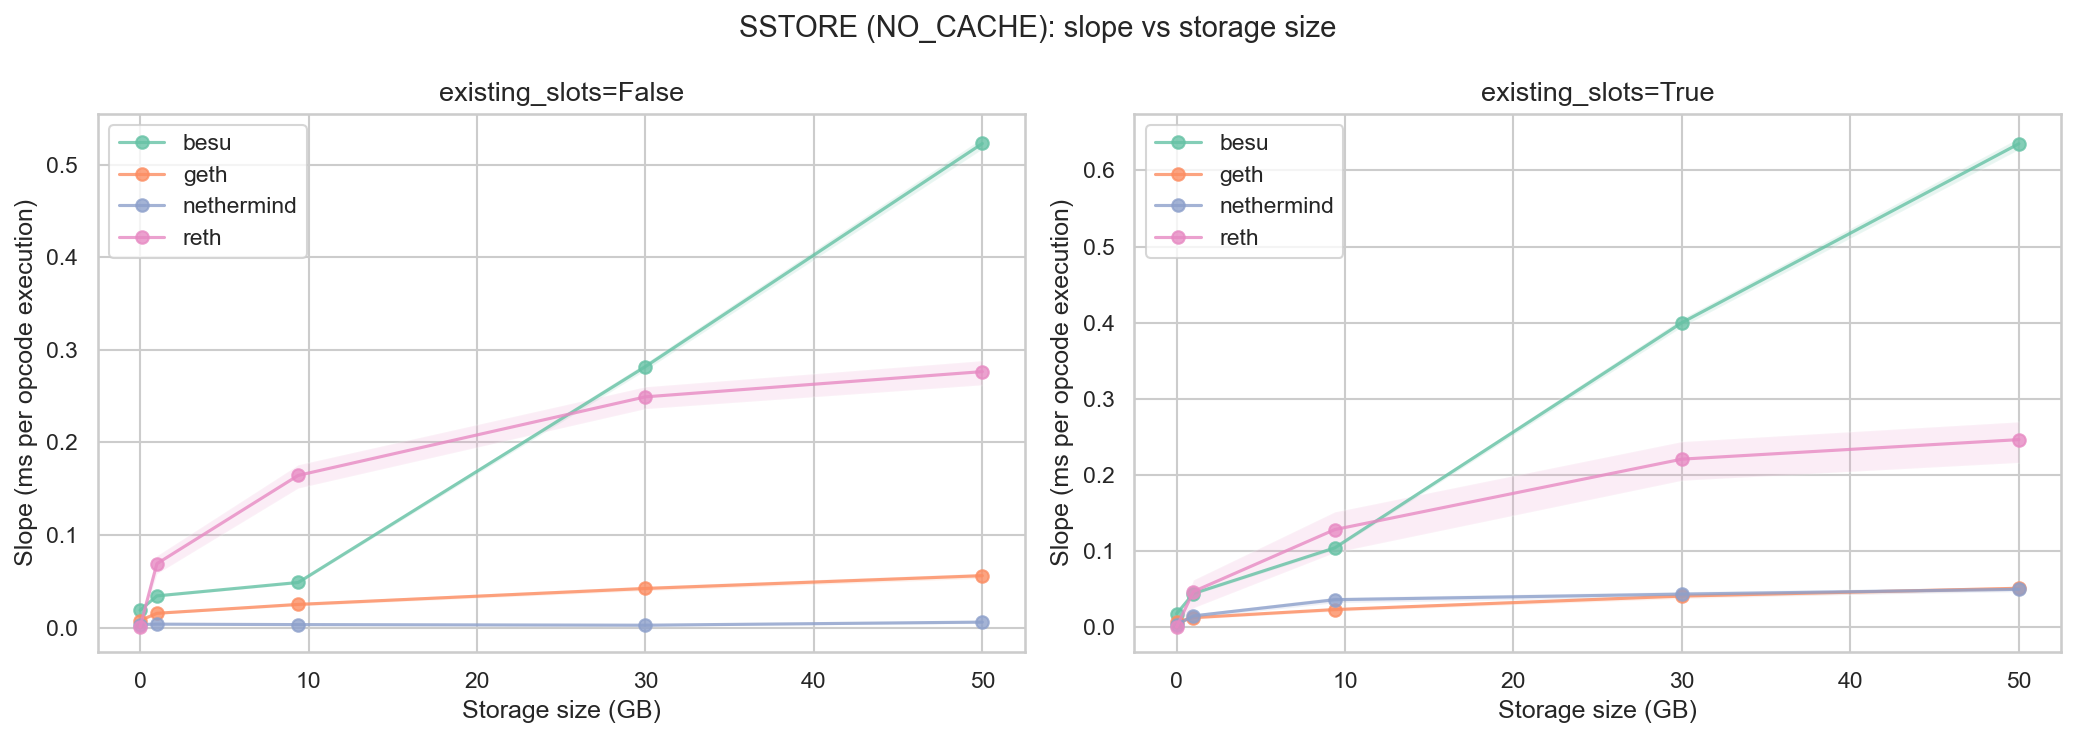

In [14]:
# Continuous view: slope vs storage_size_gb
for opcode in ["SLOAD", "SSTORE"]:
    op_results = results_df[results_df["test_opcode"] == opcode].copy()
    existing_vals = sorted(op_results["existing_slots"].unique())

    fig, axes = plt.subplots(
        1, len(existing_vals), figsize=(7 * len(existing_vals), 5), squeeze=False
    )

    for i, existing in enumerate(existing_vals):
        ax = axes[0][i]
        subset = op_results[op_results["existing_slots"] == existing]
        for client in sorted(subset["client_name"].unique()):
            client_data = subset[subset["client_name"] == client].sort_values(
                "storage_size_gb"
            )
            ax.plot(
                client_data["storage_size_gb"],
                client_data["slope"],
                marker="o",
                label=client,
                alpha=0.8,
            )
            ax.fill_between(
                client_data["storage_size_gb"],
                client_data["slope_conf_int_low"],
                client_data["slope_conf_int_high"],
                alpha=0.15,
            )
        ax.set_xlabel("Storage size (GB)")
        ax.set_ylabel("Slope (ms per opcode execution)")
        ax.set_title(f"existing_slots={existing}")
        ax.legend()

    fig.suptitle(f"{opcode} (NO_CACHE): slope vs storage size", fontsize=14)
    plt.tight_layout()
    plt.show()

For SSTORE, the `update` coefficient captures the additional cost of writing to storage. Does this also vary with storage size?

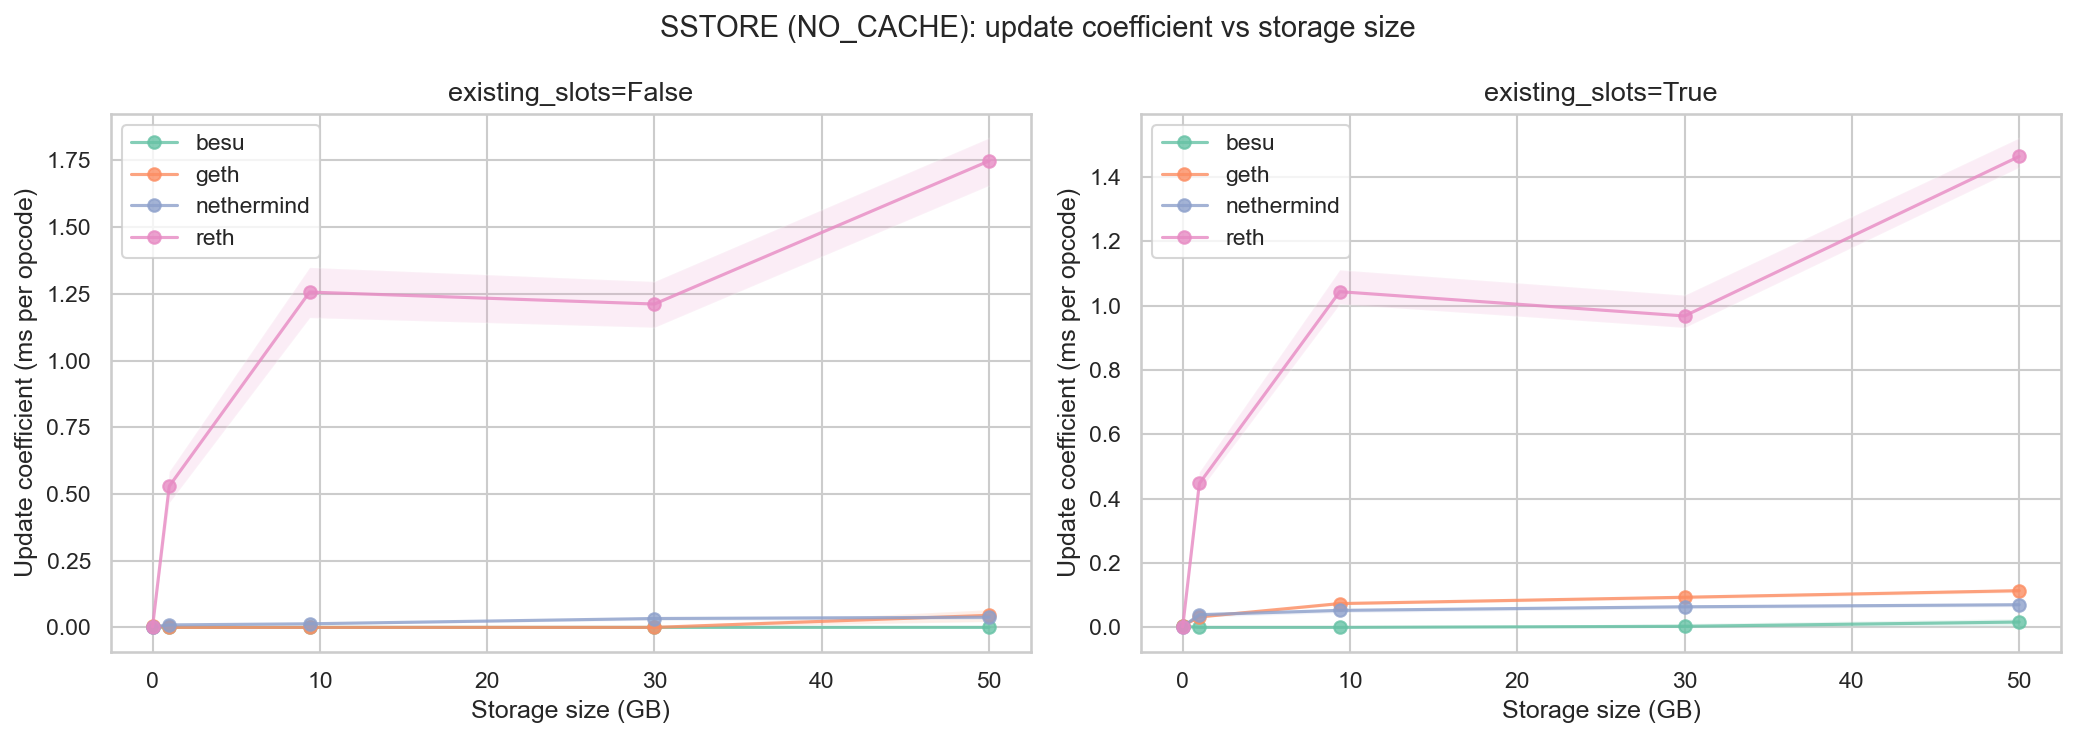

In [15]:
# SSTORE update coefficient vs storage size
sstore_results = results_df[results_df["test_opcode"] == "SSTORE"].copy()

if "update" in sstore_results.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), squeeze=False)
    for i, existing in enumerate(sorted(sstore_results["existing_slots"].unique())):
        ax = axes[0][i]
        subset = sstore_results[sstore_results["existing_slots"] == existing]
        for client in sorted(subset["client_name"].unique()):
            client_data = subset[subset["client_name"] == client].sort_values(
                "storage_size_gb"
            )
            ax.plot(
                client_data["storage_size_gb"],
                client_data["update"],
                marker="o",
                label=client,
                alpha=0.8,
            )
            ax.fill_between(
                client_data["storage_size_gb"],
                client_data["update_conf_int_low"],
                client_data["update_conf_int_high"],
                alpha=0.15,
            )
        ax.set_xlabel("Storage size (GB)")
        ax.set_ylabel("Update coefficient (ms per opcode)")
        ax.set_title(f"existing_slots={existing}")
        ax.legend()

    fig.suptitle("SSTORE (NO_CACHE): update coefficient vs storage size", fontsize=14)
    plt.tight_layout()
    plt.show()

## 6. Monotonicity and rate estimation

Runtime seems to increase with storage size. However, is the relationship linear? And how much does each addition GB of storage contribution to 
runtime?

In this section, we compute the following:

**Monotonicity tests** — do runtimes increase with storage size?
- **Spearman ρ** and **Kendall τ**: rank-based correlation tests
- **Exact permutation p-value**: computed over all 5! = 120 permutations, avoiding parametric assumptions

**Rate estimation** — by how much does each additional GB of storage increase per-opcode runtime?
- **Theil-Sen slope**: median of all $\binom{n}{2}$ pairwise slopes — robust to outliers and does not assume linearity across the full range
- **95% confidence interval** from `scipy.stats.theilslopes`

### 6.1 Slope vs storage size

In [16]:
def exact_permutation_pvalue(x, y):
    """Two-sided permutation p-value for Spearman correlation (exact for small n)."""
    observed_rho, _ = spearmanr(x, y)
    x_arr = np.array(x)
    y_arr = np.array(y)
    count = 0
    total = 0
    for perm in permutations(range(len(y_arr))):
        rho, _ = spearmanr(x_arr, y_arr[list(perm)])
        total += 1
        if abs(rho) >= abs(observed_rho):
            count += 1
    return count / total

In [17]:
monotonicity_rows = []
for opcode in ["SLOAD", "SSTORE"]:
    op_results = results_df[results_df["test_opcode"] == opcode]
    for existing in sorted(op_results["existing_slots"].unique()):
        for client in sorted(op_results["client_name"].unique()):
            subset = op_results[
                (op_results["existing_slots"] == existing)
                & (op_results["client_name"] == client)
            ].dropna(subset=["storage_size_gb", "slope"])
            if len(subset) < 3:
                continue

            sizes = subset["storage_size_gb"].values
            slopes = subset["slope"].values

            # Rank-based tests
            sp_rho, sp_p = spearmanr(sizes, slopes)
            kt_tau, kt_p = kendalltau(sizes, slopes)
            perm_p = exact_permutation_pvalue(sizes, slopes)

            # Check strict monotonicity
            sorted_subset = subset.sort_values("storage_size_gb")
            sorted_slopes = sorted_subset["slope"].values
            diffs = np.diff(sorted_slopes)
            is_monotonic = np.all(diffs > 0)

            # Theil-Sen robust rate estimation (ms per opcode per GB)
            ts_slope, ts_intercept, ts_lo, ts_hi = theilslopes(slopes, sizes)

            monotonicity_rows.append(
                {
                    "test_opcode": opcode,
                    "client_name": client,
                    "existing_slots": existing,
                    "n": len(subset),
                    "spearman_rho": sp_rho,
                    "spearman_p": sp_p,
                    "kendall_tau": kt_tau,
                    "kendall_p": kt_p,
                    "perm_p": perm_p,
                    "monotonic_increasing": is_monotonic,
                    "theilsen_slope_ms_per_gb": ts_slope,
                    "theilsen_ci_lo": ts_lo,
                    "theilsen_ci_hi": ts_hi,
                }
            )

monotonicity_df = pd.DataFrame(monotonicity_rows)

print("Monotonicity tests and rate estimation: slope vs storage_size_gb")
display(monotonicity_df.round(4))

# Summary
n_sig = (monotonicity_df["perm_p"] <= 0.05).sum()
n_mono = monotonicity_df["monotonic_increasing"].sum()
n_total = len(monotonicity_df)
print(f"\n{n_sig}/{n_total} groups have significant monotonic trend (permutation p <= 0.05)")
print(f"{n_mono}/{n_total} groups are strictly monotonically increasing")

# Theil-Sen rate summary table
print("\nEstimated additional runtime per GB of storage (Theil-Sen, ms/opcode/GB):")
rate_summary = monotonicity_df.pivot_table(
    index=["test_opcode", "existing_slots"],
    columns="client_name",
    values="theilsen_slope_ms_per_gb",
)
display(rate_summary.round(5))

Monotonicity tests and rate estimation: slope vs storage_size_gb


,test_opcode,client_name,existing_slots,n,spearman_rho,spearman_p,kendall_tau,kendall_p,perm_p,monotonic_increasing,theilsen_slope_ms_per_gb,theilsen_ci_lo,theilsen_ci_hi
0,SLOAD,besu,False,5,0.7,0.1881,0.6,0.2333,0.2333,False,0.0007,-0.0006,0.0184
1,SLOAD,geth,False,5,1.0,0.0000,1.0,0.0167,0.0167,True,0.0006,0.0005,0.0046
2,SLOAD,nethermind,False,5,-0.9,0.0374,-0.8,0.0833,0.0833,False,-0.0001,-0.0002,0.0002
3,SLOAD,reth,False,5,1.0,0.0000,1.0,0.0167,0.0167,True,0.0018,0.0004,0.0111
4,SLOAD,besu,True,5,1.0,0.0000,1.0,0.0167,0.0167,True,0.0070,0.0032,0.0215
5,SLOAD,geth,True,5,1.0,0.0000,1.0,0.0167,0.0167,True,0.0006,0.0004,0.0049
6,SLOAD,nethermind,True,5,1.0,0.0000,1.0,0.0167,0.0167,True,0.0004,0.0000,0.0022
7,SLOAD,reth,True,5,1.0,0.0000,1.0,0.0167,0.0167,True,0.0020,0.0005,0.0126
8,SSTORE,besu,False,5,1.0,0.0000,1.0,0.0167,0.0167,True,0.0100,0.0017,0.0156
9,SSTORE,geth,False,5,1.0,0.0000,1.0,0.0167,0.0167,True,0.0009,0.0007,0.0078



13/16 groups have significant monotonic trend (permutation p <= 0.05)
13/16 groups are strictly monotonically increasing

Estimated additional runtime per GB of storage (Theil-Sen, ms/opcode/GB):


client_name                    besu     geth  nethermind     reth
test_opcode existing_slots                                       
SLOAD       False           0.00070  0.00060    -0.00010  0.00181
            True            0.00695  0.00059     0.00039  0.00197
SSTORE      False           0.01003  0.00095     0.00002  0.00586
            True            0.01230  0.00093     0.00096  0.00546

In [18]:
# Convert Theil-Sen ms/opcode/GB to gas/opcode/GB using anchor: 60M gas units per second
GAS_PER_MS = 60_000_000 / 1_000  # 60,000 gas per ms

gas_rate_summary = rate_summary * GAS_PER_MS
print("Estimated additional gas cost per GB of storage (Theil-Sen, gas/opcode/GB):")
print(f"Anchor: 60M gas units per second ({GAS_PER_MS:,.0f} gas/ms)\n")
display(gas_rate_summary.round(1))

Estimated additional gas cost per GB of storage (Theil-Sen, gas/opcode/GB):
Anchor: 60M gas units per second (60,000 gas/ms)



client_name                  besu  geth  nethermind   reth
test_opcode existing_slots                                
SLOAD       False            41.7  36.3        -5.8  108.7
            True            417.0  35.1        23.4  118.0
SSTORE      False           601.8  56.8         1.0  351.9
            True            738.2  56.0        57.5  327.4

### 6.2 Update coefficient vs storage size

Same approach as 6.1 for the SSTORE `update` coefficient — does it monotonically increase with storage size, and by how much per GB?

In [19]:
update_monotonicity_rows = []
sstore_results = results_df[results_df["test_opcode"] == "SSTORE"]

for existing in sorted(sstore_results["existing_slots"].unique()):
    for client in sorted(sstore_results["client_name"].unique()):
        subset = sstore_results[
            (sstore_results["existing_slots"] == existing)
            & (sstore_results["client_name"] == client)
        ].dropna(subset=["storage_size_gb", "update"])
        if len(subset) < 3:
            continue

        sizes = subset["storage_size_gb"].values
        updates = subset["update"].values

        sp_rho, sp_p = spearmanr(sizes, updates)
        kt_tau, kt_p = kendalltau(sizes, updates)
        perm_p = exact_permutation_pvalue(sizes, updates)

        sorted_updates = subset.sort_values("storage_size_gb")["update"].values
        diffs = np.diff(sorted_updates)
        is_monotonic = np.all(diffs > 0)

        ts_slope, ts_intercept, ts_lo, ts_hi = theilslopes(updates, sizes)

        update_monotonicity_rows.append(
            {
                "client_name": client,
                "existing_slots": existing,
                "n": len(subset),
                "spearman_rho": sp_rho,
                "spearman_p": sp_p,
                "kendall_tau": kt_tau,
                "kendall_p": kt_p,
                "perm_p": perm_p,
                "monotonic_increasing": is_monotonic,
                "theilsen_slope_ms_per_gb": ts_slope,
                "theilsen_ci_lo": ts_lo,
                "theilsen_ci_hi": ts_hi,
            }
        )

update_monotonicity_df = pd.DataFrame(update_monotonicity_rows)
print("Monotonicity tests and rate estimation: update coefficient vs storage_size_gb (SSTORE only)")
display(update_monotonicity_df.round(4))

n_sig = (update_monotonicity_df["perm_p"] <= 0.05).sum()
n_mono = update_monotonicity_df["monotonic_increasing"].sum()
n_total = len(update_monotonicity_df)
print(f"\n{n_sig}/{n_total} groups have significant monotonic trend (permutation p <= 0.05)")
print(f"{n_mono}/{n_total} groups are strictly monotonically increasing")

print("\nEstimated additional update cost per GB of storage (Theil-Sen, ms/opcode/GB):")
update_rate_summary = update_monotonicity_df.pivot_table(
    index="existing_slots",
    columns="client_name",
    values="theilsen_slope_ms_per_gb",
)
display(update_rate_summary.round(5))

Monotonicity tests and rate estimation: update coefficient vs storage_size_gb (SSTORE only)


,client_name,existing_slots,n,spearman_rho,spearman_p,kendall_tau,kendall_p,perm_p,monotonic_increasing,theilsen_slope_ms_per_gb,theilsen_ci_lo,theilsen_ci_hi
0,besu,False,5,-0.7071,0.1817,-0.6325,0.1573,0.4000,False,0.0000,-0.0001,0.0000
1,geth,False,5,0.2236,0.7177,0.1195,0.7815,0.8000,False,0.0000,-0.0053,0.0023
2,nethermind,False,5,1.0000,0.0000,1.0000,0.0167,0.0167,True,0.0008,0.0002,0.0073
3,reth,False,5,0.9000,0.0374,0.8000,0.0833,0.0833,False,0.0309,-0.0022,0.5288
4,besu,True,5,0.3591,0.5528,0.3162,0.4485,0.5667,False,0.0001,-0.0035,0.0007
5,geth,True,5,1.0000,0.0000,1.0000,0.0167,0.0167,True,0.0021,0.0010,0.0278
6,nethermind,True,5,1.0000,0.0000,1.0000,0.0167,0.0167,True,0.0011,0.0003,0.0375
7,reth,True,5,0.9000,0.0374,0.8000,0.0833,0.0833,False,0.0270,-0.0037,0.4474



3/8 groups have significant monotonic trend (permutation p <= 0.05)
3/8 groups are strictly monotonically increasing

Estimated additional update cost per GB of storage (Theil-Sen, ms/opcode/GB):


client_name,besu,geth,nethermind,reth
existing_slots,,,,
False,0.00000,0.00000,0.00077,0.03086
True,0.00014,0.00215,0.00111,0.02703


In [20]:
# Convert Theil-Sen ms/opcode/GB to gas/opcode/GB for update coefficient
gas_update_rate_summary = update_rate_summary * GAS_PER_MS
print("Estimated additional update gas cost per GB of storage (Theil-Sen, gas/opcode/GB):")
print(f"Anchor: 60M gas units per second ({GAS_PER_MS:,.0f} gas/ms)\n")
display(gas_update_rate_summary.round(1))

Estimated additional update gas cost per GB of storage (Theil-Sen, gas/opcode/GB):
Anchor: 60M gas units per second (60,000 gas/ms)



client_name,besu,geth,nethermind,reth
existing_slots,,,,
False,0.0,0.0,46.4,1851.7
True,8.2,128.9,66.4,1621.6


### 6.3 Comparing existing vs non-existing slots

Is the storage size impact different for existing vs non-existing slot variants?

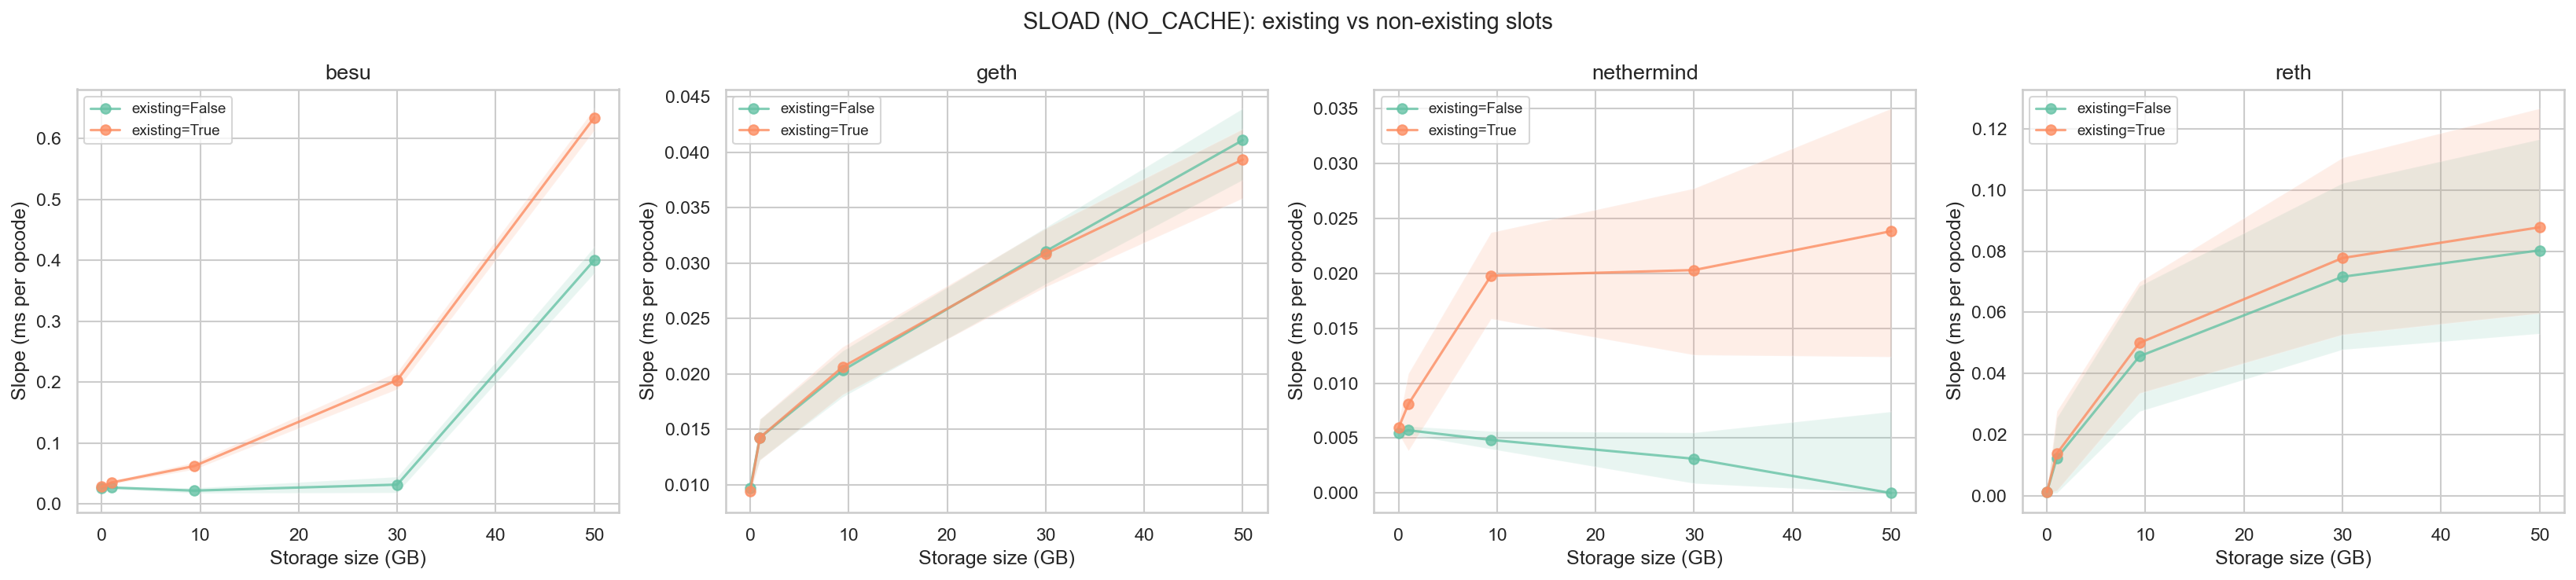

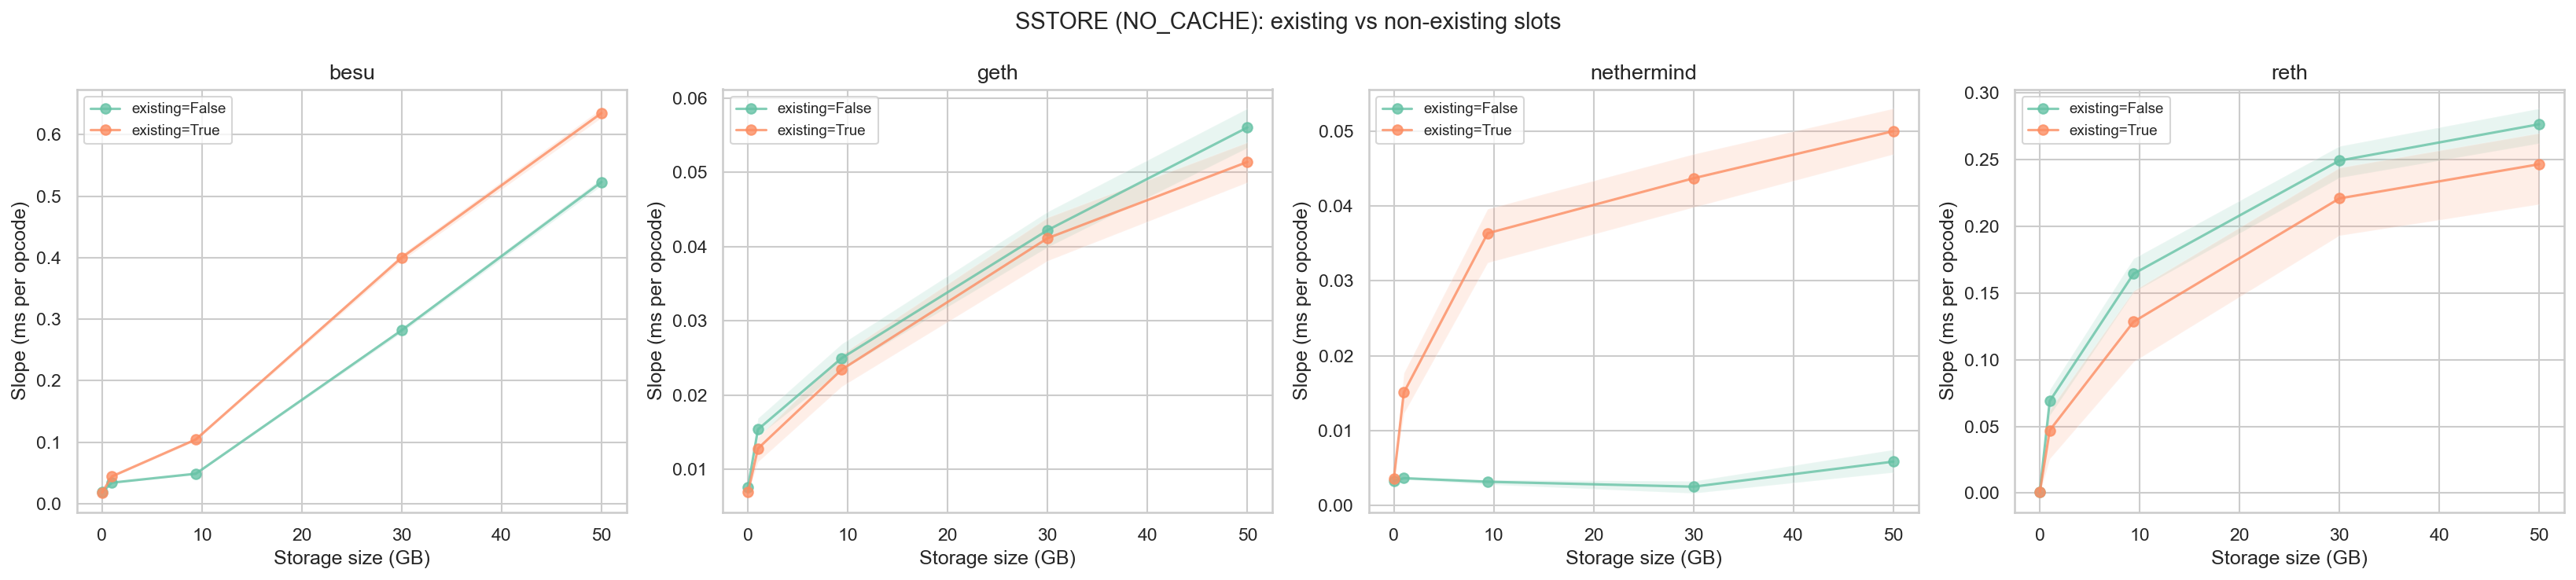

In [21]:
# Side-by-side comparison: existing vs non-existing slots
for opcode in ["SLOAD", "SSTORE"]:
    op_results = results_df[results_df["test_opcode"] == opcode]
    clients = sorted(op_results["client_name"].unique())

    fig, axes = plt.subplots(1, len(clients), figsize=(5.5 * len(clients), 5))
    if len(clients) == 1:
        axes = [axes]

    for i, client in enumerate(clients):
        ax = axes[i]
        client_data = op_results[op_results["client_name"] == client]

        for existing in sorted(client_data["existing_slots"].unique()):
            subset = client_data[client_data["existing_slots"] == existing].sort_values(
                "storage_size_gb"
            )
            label = f"existing={existing}"
            ax.plot(
                subset["storage_size_gb"],
                subset["slope"],
                marker="o",
                label=label,
                alpha=0.8,
            )
            ax.fill_between(
                subset["storage_size_gb"],
                subset["slope_conf_int_low"],
                subset["slope_conf_int_high"],
                alpha=0.15,
            )
        ax.set_xlabel("Storage size (GB)")
        ax.set_ylabel("Slope (ms per opcode)")
        ax.set_title(f"{client}")
        ax.legend(fontsize=9)

    fig.suptitle(f"{opcode} (NO_CACHE): existing vs non-existing slots", fontsize=14)
    plt.tight_layout()
    plt.show()

In [22]:
# Summary table: slope by opcode, client, existing_slots, and token_name
summary_pivot = results_df.pivot_table(
    index=["test_opcode", "client_name", "existing_slots"],
    columns="token_name",
    values="slope",
)
# Reorder columns by storage size
ordered_cols = [t for t in token_order if t in summary_pivot.columns]
summary_pivot = summary_pivot[ordered_cols]

print("Slope (ms per opcode) by combination:")
display(summary_pivot.round(4))

Slope (ms per opcode) by combination:


token_name                              4_23MB_ERC20  1GB_ERC20  9_39GB_ERC20  \
test_opcode client_name existing_slots                                          
SLOAD       besu        False                 0.0262     0.0271        0.0221   
                        True                  0.0284     0.0354        0.0623   
            geth        False                 0.0097     0.0142        0.0203   
                        True                  0.0094     0.0143        0.0206   
            nethermind  False                 0.0055     0.0057        0.0048   
                        True                  0.0059     0.0081        0.0198   
            reth        False                 0.0013     0.0124        0.0456   
                        True                  0.0013     0.0138        0.0500   
SSTORE      besu        False                 0.0187     0.0342        0.0487   
                        True                  0.0180     0.0444        0.1044   
            geth        False                 0.0076     0.0154        0.0250   
                        True                  0.0069     0.0128        0.0234   
            nethermind  False                 0.0033     0.0036        0.0032   
                        True                  0.0036     0.0151        0.0364   
            reth        False                 0.0008     0.0690        0.1644   
                        True                  0.0006     0.0471        0.1284   

token_name                              30GB_ERC20  50GB_ERC20  
test_opcode client_name existing_slots                          
SLOAD       besu        False               0.0319      0.4004  
                        True                0.2035      0.6343  
            geth        False               0.0311      0.0411  
                        True                0.0308      0.0393  
            nethermind  False               0.0031      0.0000  
                        True                0.0203      0.0238  
            reth        False               0.0716      0.0803  
                        True                0.0778      0.0878  
SSTORE      besu        False               0.2819      0.5229  
                        True                0.4001      0.6350  
            geth        False               0.0422      0.0560  
                        True                0.0411      0.0514  
            nethermind  False               0.0025      0.0059  
                        True                0.0437      0.0500  
            reth        False               0.2492      0.2765  
                        True                0.2209      0.2465

## Summary

1. **Model fit quality (R² and p-values)**: SSTORE fits are generally strong (besu mean R²=0.975, geth/nethermind/reth ~0.78–0.80), while SLOAD fits are more variable (besu 0.77, nethermind 0.53). 12 out of 80 models have R² < 0.5 or slope p > 0.05, concentrated in SLOAD for larger storage sizes (30GB, 50GB) — particularly for nethermind (R²=0.000 for 50GB non-existing SLOAD) and besu/reth at 30GB. Slope p-values are universally significant (p=0) except for some nethermind SLOAD models. The SSTORE `update` coefficient is significant for nethermind and reth but **not** for besu and geth (max p=1.0), suggesting the update/non-update distinction matters only for some clients.

2. **Storage size impact on SLOAD slope**: Per-opcode runtime clearly increases with storage size for most clients. The effect is dramatic for **besu** (0.026 → 0.400 ms at 50GB for non-existing slots, 0.028 → 0.634 ms for existing) and substantial for **reth** (0.001 → 0.080 ms) and **geth** (0.010 → 0.041 ms). **Nethermind** shows the weakest and most inconsistent trend. Existing-slot slopes are generally higher than non-existing at large storage sizes (besu: 0.634 vs 0.400 at 50GB; reth: 0.088 vs 0.080), with the gap widening as storage grows — though geth is an exception where non-existing is slightly higher at 50GB (0.041 vs 0.039).

3. **Storage size impact on SSTORE slope and update coefficient**: SSTORE slopes increase monotonically with storage size across all clients. **Besu** is the most sensitive (0.019 → 0.523 ms for non-existing, 0.018 → 0.635 ms for existing). **Reth** also shows strong sensitivity (up to 0.277 ms at 50GB). **Geth** shows a moderate, consistent increase. **Nethermind** is again the least affected — non-existing slot slopes stay nearly flat (0.003–0.006 ms), though existing slots do rise to 0.050 ms. The update coefficient does not show a clear storage-size dependency for besu and geth (where it is not statistically significant).

4. **Monotonicity of slope vs storage size**: Exact permutation tests (over all 5! = 120 orderings) confirm that **13 out of 16** client/opcode/slot groups show a statistically significant monotonic increase in slope with storage size (p ≤ 0.05), with 13/16 being strictly monotonically increasing. The three exceptions are SLOAD non-existing slots for besu (p=0.23) and nethermind (p=0.08, with a *negative* Spearman ρ=−0.9), and SSTORE non-existing slots for nethermind (p=0.95) — all driven by poor underlying model fits at large storage sizes.

5. **Monotonicity of SSTORE update coefficient**: The update coefficient shows a weaker storage-size dependency: only **3 out of 8** groups are significant (nethermind for both slot types and geth for existing slots). Besu and reth update coefficients do not increase monotonically with storage size, consistent with the update coefficient being statistically insignificant for besu/geth in the NNLS fits.

6. **Per-GB rate estimates (Theil-Sen)**: Robust Theil-Sen slopes quantify the marginal cost per additional GB of storage. For SLOAD slopes, rates range from ~0.0004 ms/opcode/GB (nethermind existing) to ~0.007 ms/opcode/GB (besu existing). For SSTORE slopes, rates range from ~0.001 ms/opcode/GB (geth/nethermind) to ~0.012 ms/opcode/GB (besu existing). Converted to gas at 60M gas/s: SLOAD per-GB costs are **36–417 gas/opcode/GB** (besu/reth highest), and SSTORE per-GB costs are **57–738 gas/opcode/GB** (besu highest at 738 gas/opcode/GB for existing slots). Nethermind rates are negligible or negative for non-existing SLOAD.

7. **Client differences**: Clients differ substantially in their sensitivity to storage size. **Besu** is by far the most affected — slopes at 50GB are 10–35× larger than at 4MB, for both SLOAD and SSTORE, with the highest per-GB gas rates (up to 738 gas/opcode/GB). **Reth** is the second most sensitive (109–352 gas/opcode/GB). **Geth** shows moderate, consistent increases (~4–7×, 35–57 gas/opcode/GB). **Nethermind** is the least sensitive, with slopes staying low even at 50GB, though this may partly reflect poor model fits at large storage sizes.